# SHAP Exercise:
#### **How Do Different SHAP Methods Explain the Same Image?**

SHAP has different **explainers** that use different strategies to compute the Shapley values. In this exercise, you'll apply different explainers to the same image and compare their explanations.

## Setup and Imports
Start by setting up a new virtual environment with the packages specified in requirements_shap.txt.
I tested the scripts with python 3.11 but newer versions probably also work.

Then download the *poodle.png* and *imagenet_classes.txt* from Moodle into a folder called Data. Since we will reuse this folder, you can create it one level above the folder for this SHAP exercise.

Then:

In [2]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import requests
from skimage.segmentation import slic
import shap
import cv2

device = torch.device("cpu")
print(f"Using device: {device}")

d:\College\THI\XAI-HCI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [3]:
# Load pre-trained VGG16
model = models.vgg16(weights="IMAGENET1K_V1")
model.eval()
model = model.to(device)

# Load ImageNet class names
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
response = requests.get(url)
class_names = [line.strip() for line in response.text.split('\n')]
print(f"Model loaded. {len(class_names)} classes.")

Model loaded. 1000 classes.


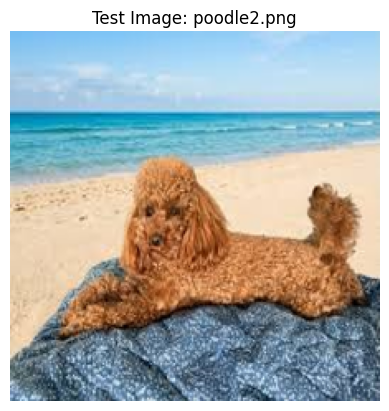

In [18]:
# Path to images
data_path = Path("../data")
img_name = "poodle2.png"

# Load image
img_path = data_path / img_name
if img_path.exists():
    original_img = Image.open(img_path).convert('RGB')
else:
    print("Image not found, creating placeholder")
    original_img = Image.new('RGB', (224, 224), color='gray')

original_img = original_img.resize((224, 224))
img_array = np.array(original_img)

plt.imshow(original_img)
plt.title(f"Test Image: {img_name}")
plt.axis('off')
plt.show()

In [5]:
# Preprocessing for Imagenet like data
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

# Get model prediction
img_tensor = preprocess(original_img).unsqueeze(0).to(device)
with torch.no_grad():
    output = model(img_tensor)
    probs = torch.nn.functional.softmax(output[0], dim=0)
    top5 = torch.argsort(probs, descending=True)[:5]

predicted_class = top5[0].item()
print(f"\nPredicted: {class_names[predicted_class]} ({probs[predicted_class]:.3f})")
print("\nTop 5 predictions:")
for i, idx in enumerate(top5):
    print(f"  {i+1}. {class_names[idx]}: {probs[idx]:.3f}")


Predicted: toy poodle (0.763)

Top 5 predictions:
  1. toy poodle: 0.763
  2. miniature poodle: 0.235
  3. standard poodle: 0.001
  4. teddy: 0.000
  5. Blenheim spaniel: 0.000


## Prediction Function
The SHAP library implements different variations of SHAP in functions called *explainers*.
All SHAP explainers need a function that takes images and returns predictions.

In [6]:
def model_predict(images, batch_size=16):
    """
    Predict class probabilities for a batch of images.
    Processes in small chunks to avoid out-of-memory errors.

    Args:
        images: numpy array of shape (n_samples, H, W, 3) with values in [0, 255]
        batch_size: how many images to process at once

    Returns:
        numpy array of shape (n_samples, n_classes) with probabilities
    """
    images = images.astype(np.uint8)
    n = images.shape[0]
    all_probs = []

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        chunk = images[start:end]

        batch = torch.stack([preprocess(img) for img in chunk]).to(device)

        with torch.no_grad():
            logits = model(batch)
            probs = torch.nn.functional.softmax(logits, dim=1)

        all_probs.append(probs.cpu().numpy())

    return np.concatenate(all_probs, axis=0)

# KernelSHAP
We will start with the basic KernelSHAP explainer which we saw in the lecture.

**Reminder how it works**: Kernel SHAP approximates Shapley values by sampling coalitions of features (here, superpixels) and weighting them with a Shapley kernel; it is model‑agnostic but relatively slow.

## Masking

The SHAP library needs a masking function to represent "feature absent" perturbation. 
For our image data and KernelSHAP, we will use a superpixel segmentation approach similar to LIME, as discussed in the lecture. 
To this end, we first segement the image using the SLIC algorithm. If you want, you can play around with the hyperparameters of SLIC.

In [7]:
# Superpixels
n_segments = 50 # Number of superpixels
segments = slic(img_array, n_segments=n_segments, compactness=30, sigma=3, start_label=0) # This returns a 2D integer array assigning a superpixel id to each pixel.


In addition, SHAP requires a background data for perturbation. In our case this background data simply defines the "color" that is used to perturb the superpixels.
Let's start with a simple perturbation using only black color:

In [8]:
background = np.zeros((1, 224, 224, 3), dtype=np.uint8)

Now, we can create custom masking functions to perturb the image and get the models prediction on this perturbed sample. 

In [9]:
def mask_image_kernel(masks, segmentation, image, background):
    """
    Convert binary coalition masks over superpixels into perturbed images.
    """
    # Handle background passed as (1,H,W,3) or (H,W,3)
    bg = background[0] if background.ndim == 4 else background

    n_masks = masks.shape[0]
    H, W, C = image.shape
    out = np.zeros((n_masks, H, W, C), dtype=image.dtype)

    for i in range(n_masks):
        # Fancy-index: map each pixel's segment id to its coalition bit
        keep = masks[i][segmentation].astype(bool)
        # Where keep is True use original, else use background
        out[i] = np.where(keep[..., None], image, bg)

    return out


def f_kernel(masks):
    """
    Prediction function that takes coalition masks and returns class probabilities.
    """
    perturbed = mask_image_kernel(masks, segments, img_array, background)
    return model_predict(perturbed)

## KernelExplainer

Now that we have the necessary auxiliary functions, let's create our SHAP explanation.
Use the *KernelExplainer* class and its *shap_values* method to explain our poodle image.
Hint: The KernelExplainer expects the background argument in binary coalition mask form.
- See SHAP docs: [shap.KernelExplainer](https://shap.readthedocs.io/en/latest/generated/shap.KernelExplainer.html)


In [10]:
# Number of actual segments (SLIC's n_segments is a target, not exact)
n_segs = int(segments.max()) + 1

# Reference coalition: all superpixels absent
background_coalition = np.zeros((1, n_segs))

# Point to explain: all superpixels present (original image)
full_coalition = np.ones((1, n_segs))

# Create and run KernelExplainer
explainer_kernel = shap.KernelExplainer(f_kernel, background_coalition)
shap_values_kernel = explainer_kernel.shap_values(full_coalition, nsamples=500)

# Extract SHAP values for predicted class (handle both old and new SHAP API)
if isinstance(shap_values_kernel, list):
    sv_for_class = shap_values_kernel[predicted_class][0]
else:
    sv_for_class = shap_values_kernel[0, :, predicted_class]

print(f"SHAP values shape: {sv_for_class.shape}")

100%|██████████| 1/1 [01:25<00:00, 85.58s/it]

SHAP values shape: (49,)


Now, use the shap.image_plot method to visualize your result. 
Hint: you might need another helper function.
- See SHAP docs: [shap.image_plot]( https://shap.readthedocs.io/en/latest/generated/shap.plots.image.html)

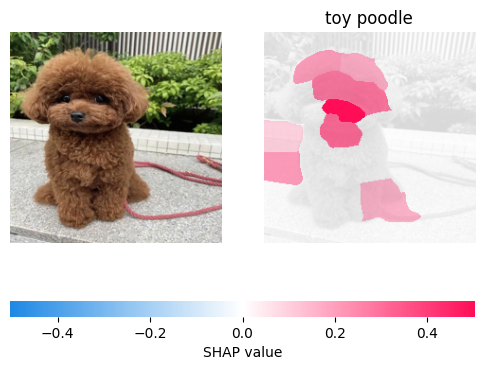

In [11]:
def shap_per_pixel(sv_segments, segmentation):
    """Broadcast per-segment SHAP values out to per-pixel (H, W, 3)."""
    pix = sv_segments[segmentation]
    return np.repeat(pix[..., None], 3, -1)

sv_pixels = shap_per_pixel(sv_for_class, segments)

shap.image_plot(
    shap_values=[sv_pixels],
    pixel_values=img_array,
    labels=[[class_names[predicted_class]]],
)

## Different Background
Now lets try a random background for perturbation instead of black. 
Create a background image with random pixels (an image where each pixel has random values between 0 and 255) and use this for our custom masking function.
Then, see how this changes the explanation for your example image.

100%|██████████| 1/1 [01:25<00:00, 85.81s/it]


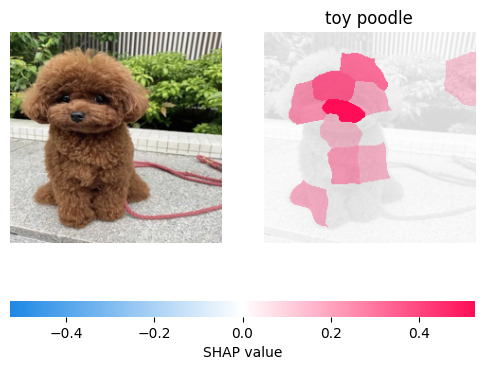

In [12]:
background_random = np.random.randint(0, 256, (1, 224, 224, 3), dtype=np.uint8)

def f_kernel_random(masks):
    perturbed = mask_image_kernel(masks, segments, img_array, background_random)
    return model_predict(perturbed)

explainer_random = shap.KernelExplainer(f_kernel_random, np.zeros((1, n_segs)))
shap_values_random = explainer_random.shap_values(np.ones((1, n_segs)), nsamples=500)

if isinstance(shap_values_random, list):
    sv_random_class = shap_values_random[predicted_class][0]
else:
    sv_random_class = shap_values_random[0, :, predicted_class]

sv_random_pixels = shap_per_pixel(sv_random_class, segments)

shap.image_plot(
    shap_values=[sv_random_pixels],
    pixel_values=img_array,
    labels=[[class_names[predicted_class]]],
)

# PartitionSHAP

Now, we will look at a different way to calculate SHAP values: the PartitionExplainer.

**How it works**: Uses a hierarchical feature partition tree and a masking function (for images, shap.maskers.Image) to efficiently approximate Shapley values, making it much faster than kernel-based methods for structured inputs.
See SHAP docs: 
- [shap.PartitionExplainer](https://shap.readthedocs.io/en/latest/generated/shap.PartitionExplainer.html)
- [shap.maskers.Image](https://shap.readthedocs.io/en/latest/generated/shap.maskers.Image.html)

## ParitionExplainer with Inpainting

In the first PartitionExplainer example, we will use inpainting to mask the images. Here the masking tries to reconstruct the selected image area from the pixels near the area boundary. This leads to more realistic perturbations than using a constant color.

In [ ]:
# Image masker
masker = shap.maskers.Image("inpaint_telea", img_array.shape)

# Create Partition explainer
explainer_partition = shap.PartitionExplainer(model_predict, masker)

# Compute SHAP values (img_array needs a batch dimension → shape (1, 224, 224, 3))
shap_values_partition = explainer_partition(
    img_array[np.newaxis],
    max_evals=750,
    batch_size=16
)

PartitionExplainer explainer: 2it [01:34, 94.61s/it]               


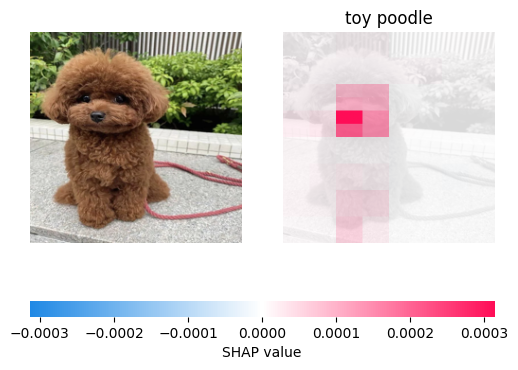

In [15]:
# shap_values_partition has shape (1, H, W, 3, n_classes)
# Slice to just the predicted class → shape (1, H, W, 3)
shap.image_plot(
    shap_values=shap_values_partition[..., predicted_class].values,
    pixel_values=img_array[np.newaxis],
    labels=[[class_names[predicted_class]]]
)

## PartitionExplainer with Blur Masking

Now, let's try to use an image masker with a blur value (e.g. "blur(128,128)") so that masked regions are replaced by a blurred version of the image, representing “feature absent” via smoothing instead of inpainting or a fixed background.
- See SHAP docs: [shap.maskers.Image](https://shap.readthedocs.io/en/latest/generated/shap.maskers.Image.html)


In [19]:
# Adjust masker to use 128x128 blurring instead of inpainting
masker_blur = shap.maskers.Image("blur(128,128)", img_array.shape)

# Create Partition explainer
explainer_blur = shap.PartitionExplainer(model_predict, masker_blur)

# Compute SHAP values
shap_values_blur = explainer_blur(
    img_array[np.newaxis],
    max_evals=500,
    batch_size=16
)

PartitionExplainer explainer: 2it [01:32, 92.97s/it]               


MemoryError: Unable to allocate 2.24 GiB for an array with shape (1, 301055, 1000) and data type float64

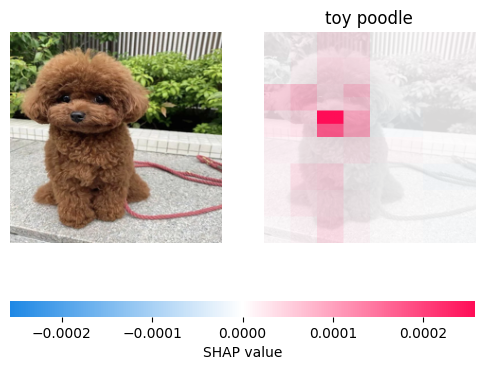

In [ ]:
shap.image_plot(
    shap_values=shap_values_blur[..., predicted_class].values,
    pixel_values=img_array[np.newaxis],
    labels=[[class_names[predicted_class]]]
)